**IMPORTING LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

**LOAD & CLEAN DATA**

In [2]:
df = pd.read_excel("Mosoriot Data.xlsx")

df.columns = df.columns.str.strip()
df.drop('Serial No', axis=1, inplace=True)
df.head()

,Age,Sex,Marital Status,Level of Education,Have you heard about SHA?,Where did you hear about SHA,Do you know how someone can register for SHA?,"In your opinion, how sufficient is the knowledge you have about SHA?",Are you currently registered under SHA?,How long have you been enrolled?,...,Has SHA helped reduce the amount of money you personally spend on healthcare?,Are there healtcare services you stilll have to pay for after enrolling in SHA?,Have you experienced any difficulties when trying to access healthcare services through SHA?,Do you think the registration process for SHA is easy ordifficult?,SHA has improved my ability to receive medical care,Medicines are usually available when I visit the facility,The services covered by SHA meet my healthcare needs,SHA has reduced my personal spending on SHA,I feel financially protected when seeking treatment under SHA,Would you recommend SHA to older adults?
0,70,1,1,4,1,4,1,5,1,2,...,1,1,5,2,4,2,5,5,5,1
1,80,1,1,4,1,3,1,4,1,1,...,1,2,5,2,5,5,5,5,5,1
2,68,2,2,2,1,4,2,2,1,1,...,1,2,5,2,5,5,5,5,5,1
3,62,1,1,2,1,"1,2",1,5,1,2,...,1,2,5,3,3,3,3,5,5,1
4,62,2,2,2,1,1,2,2,1,2,...,1,1,5,2,5,3,5,5,5,1


**Basic exploration**

In [3]:
df.shape

(50, 22)

In [4]:
df.columns

Index(['Age', 'Sex', 'Marital Status', 'Level of Education',
       'Have you heard about SHA?', 'Where did you hear about SHA',
       'Do you know how someone can register for SHA?',
       'In your opinion, how sufficient is the knowledge you have about SHA?',
       'Are you currently registered under SHA?',
       'How long have you been enrolled?',
       'How often do you visit a health facility now compared to before enrolling?',
       'What types of health services have you accessed through SHA?',
       'Has SHA helped reduce the amount of money you personally spend on healthcare?',
       'Are there healtcare services you stilll have to pay for after enrolling in SHA?',
       'Have you experienced any difficulties when trying to access healthcare services through SHA?',
       'Do you think the registration process for SHA is easy ordifficult?',
       'SHA has improved my ability to receive medical care',
       'Medicines are usually available when I visit the facility',

**MAPPING OF CATEGORICAL VARIABLES**

In [5]:
yesNo = {
    0: 'No response',
    1: 'Yes',
    2: 'No',
    3: 'Not Sure',
}

sex = {
    0: 'No response',
    1: 'Male',
    2: 'Female'
}

maritalStatus = {
    0: 'No response',
    1: 'Married',
    2: 'Widowed',
    3: 'Single',
    4: 'Divorced/Separated',
}
education = {
    0: 'No response',
    1: 'No formal education',
    2: 'Primary',
    3: 'Secondary',
    4: 'Tertiary',
    5: 'Other',
}
sufficiency = {
    0: 'No response',
    1: 'Very insufficienct',
    2: 'Insufficient',
    3: 'Neutral',
    4: 'Sufficient',
    5: 'Very Sufficient'
}

enrollmentTime = {
    0: 'No response',
    1: 'Less than 1 year',
    2: '1-2 years',
    3: 'Not Sure'
}

visits = {
    0: 'No response',
    1: 'More Often',
    2: 'Less Often',
    3: 'The Same',
}

ease = {
    0: 'No response',
    1: 'Very easy',
    2: 'Easy',
    3: 'Neutral',
    4: 'Hard',
    5: 'Very Hard'
}

agreement = {
    0: 'No response',
    1: 'Strongly Disagree',
    2: 'Disagree',
    3: 'Neutral',
    4: 'Agree',
    5: 'Strongly Agree',
}

# Apply Mappings

df['Sex'] = df['Sex'].map(sex)
df['Marital Status'] = df['Marital Status'].map(maritalStatus)
df['Level of Education'] = df['Level of Education'].map(education)

df['Have you heard about SHA?'] = df['Have you heard about SHA?'].map(yesNo)
df['Do you know how someone can register for SHA?'] = df['Do you know how someone can register for SHA?'].map(yesNo)
df['Are you currently registered under SHA?'] = df['Are you currently registered under SHA?'].map(yesNo)

df['In your opinion, how sufficient is the knowledge you have about SHA?'] = df['In your opinion, how sufficient is the knowledge you have about SHA?'].map(sufficiency)
df['How long have you been enrolled?'] = df['How long have you been enrolled?'].map(enrollmentTime)
df['How often do you visit a health facility now compared to before enrolling?'] = df['How often do you visit a health facility now compared to before enrolling?'].map(visits)

df['Has SHA helped reduce the amount of money you personally spend on healthcare?'] = df['Has SHA helped reduce the amount of money you personally spend on healthcare?'].map(yesNo)
df['Are there healtcare services you stilll have to pay for after enrolling in SHA?'] = df['Are there healtcare services you stilll have to pay for after enrolling in SHA?'].map(yesNo)

df['Do you think the registration process for SHA is easy ordifficult?'] = df['Do you think the registration process for SHA is easy ordifficult?'].map(ease)

# Likert scale columns
likert_cols = [
    'SHA has improved my ability to receive medical care',
    'Medicines are usually available when I visit the facility',
    'The services covered by SHA meet my healthcare needs',
    'SHA has reduced my personal spending on SHA',
    'I feel financially protected when seeking treatment under SHA'
]

for c in likert_cols: 
    df[c] = df[c].map(agreement)

df['Would you recommend SHA to older adults?'] = df['Would you recommend SHA to older adults?'].map(yesNo)
df.head()

,Age,Sex,Marital Status,Level of Education,Have you heard about SHA?,Where did you hear about SHA,Do you know how someone can register for SHA?,"In your opinion, how sufficient is the knowledge you have about SHA?",Are you currently registered under SHA?,How long have you been enrolled?,...,Has SHA helped reduce the amount of money you personally spend on healthcare?,Are there healtcare services you stilll have to pay for after enrolling in SHA?,Have you experienced any difficulties when trying to access healthcare services through SHA?,Do you think the registration process for SHA is easy ordifficult?,SHA has improved my ability to receive medical care,Medicines are usually available when I visit the facility,The services covered by SHA meet my healthcare needs,SHA has reduced my personal spending on SHA,I feel financially protected when seeking treatment under SHA,Would you recommend SHA to older adults?
0,70,Male,Married,Tertiary,Yes,4,Yes,Very Sufficient,Yes,1-2 years,...,Yes,Yes,5,Easy,Agree,Disagree,Strongly Agree,Strongly Agree,Strongly Agree,Yes
1,80,Male,Married,Tertiary,Yes,3,Yes,Sufficient,Yes,Less than 1 year,...,Yes,No,5,Easy,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Yes
2,68,Female,Widowed,Primary,Yes,4,No,Insufficient,Yes,Less than 1 year,...,Yes,No,5,Easy,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Yes
3,62,Male,Married,Primary,Yes,"1,2",Yes,Very Sufficient,Yes,1-2 years,...,Yes,No,5,Neutral,Neutral,Neutral,Neutral,Strongly Agree,Strongly Agree,Yes
4,62,Female,Widowed,Primary,Yes,1,No,Insufficient,Yes,1-2 years,...,Yes,Yes,5,Easy,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Strongly Agree,Yes


**CREATE A CLEAN MAIN DATASET**

In [6]:
df_main = df.copy()

**CLEAN AND EXPLODE**

In [7]:
# Function to clean & explode
def explode_column (dataframe, column_name):
    df_temp = dataframe.copy()

    df_temp[column_name] = df_temp[column_name].astype(str).str.replace(" ", "")
    df_temp[column_name] = df_temp[column_name].replace("nan", pd.NA)
    df_temp[column_name] = df[column_name].dropna().apply(lambda x: str(x).split(','))

    df_temp = df_temp.explode(column_name)
    df_temp = df_temp.dropna(subset=[column_name])

    df_temp[column_name] = df_temp[column_name].astype(int)

    return df_temp

# Creating exploded data sets
# 1. Sources of Information
df_sources = explode_column(df_main, 'Where did you hear about SHA')
sources = {
    0: 'No Response',
    1: 'Radio',
    2: 'Television',
    3: 'Community Meetings',
    4: 'Health Workers',
    5: 'Family/Friends',
    6: 'Mobile Phone',
    7: 'Social Media',
    8: 'Other',
}
df_sources['Where did you hear about SHA'] = df_sources['Where did you hear about SHA'].map(sources)

# 2. Services accessed
df_services = explode_column(df_main, 'What types of health services have you accessed through SHA?')
services = {
    0: 'No response',
    1: 'Outpatient Services',
    2: 'Inpatient Services',
    3: 'Medications',
    4: 'Laboratory Tests',
    5: 'Other', 
}
df_services['What types of health services have you accessed through SHA?'] = df_services['What types of health services have you accessed through SHA?'].map(services)

# 3. Difficulties
df_difficulties = explode_column(df_main, 'Have you experienced any difficulties when trying to access healthcare services through SHA?')
difficulties = {
    0: 'No Response',
    1: 'Lack of information',
    2: 'Difficulty registering',
    3: 'Technological difficulties',
    4: 'Transport Cost',
    5: 'Other'
}
df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'] = df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'].map(difficulties)

**BASIC ANALYSIS**

**Demographics**

*Age Summary*

In [8]:
print(df_main['Age'].describe())
print("Median Age: ", df_main['Age'].median())

count    50.000000
mean     69.380000
std       8.020102
min      60.000000
25%      62.000000
50%      69.500000
75%      74.500000
max      89.000000
Name: Age, dtype: float64
Median Age:  69.5


*Sex Distribution*

In [9]:
print(df_main['Sex'].value_counts())
print(df_main['Sex'].value_counts(normalize=True) * 100)

Sex
Male      26
Female    24
Name: count, dtype: int64
Sex
Male      52.0
Female    48.0
Name: proportion, dtype: float64


*Marriage Status*

In [10]:
print(df_main['Marital Status'].value_counts())
print(df_main['Marital Status'].value_counts(normalize=True) * 100)

Marital Status
Married    36
Widowed    14
Name: count, dtype: int64
Marital Status
Married    72.0
Widowed    28.0
Name: proportion, dtype: float64


*Level of Education*

In [11]:
print(df_main['Level of Education'].value_counts())
print(df_main['Level of Education'].value_counts(normalize=True) * 100)

Level of Education
Primary                25
Secondary              14
No formal education     6
Tertiary                4
Other                   1
Name: count, dtype: int64
Level of Education
Primary                50.0
Secondary              28.0
No formal education    12.0
Tertiary                8.0
Other                   2.0
Name: proportion, dtype: float64


*Visualization*

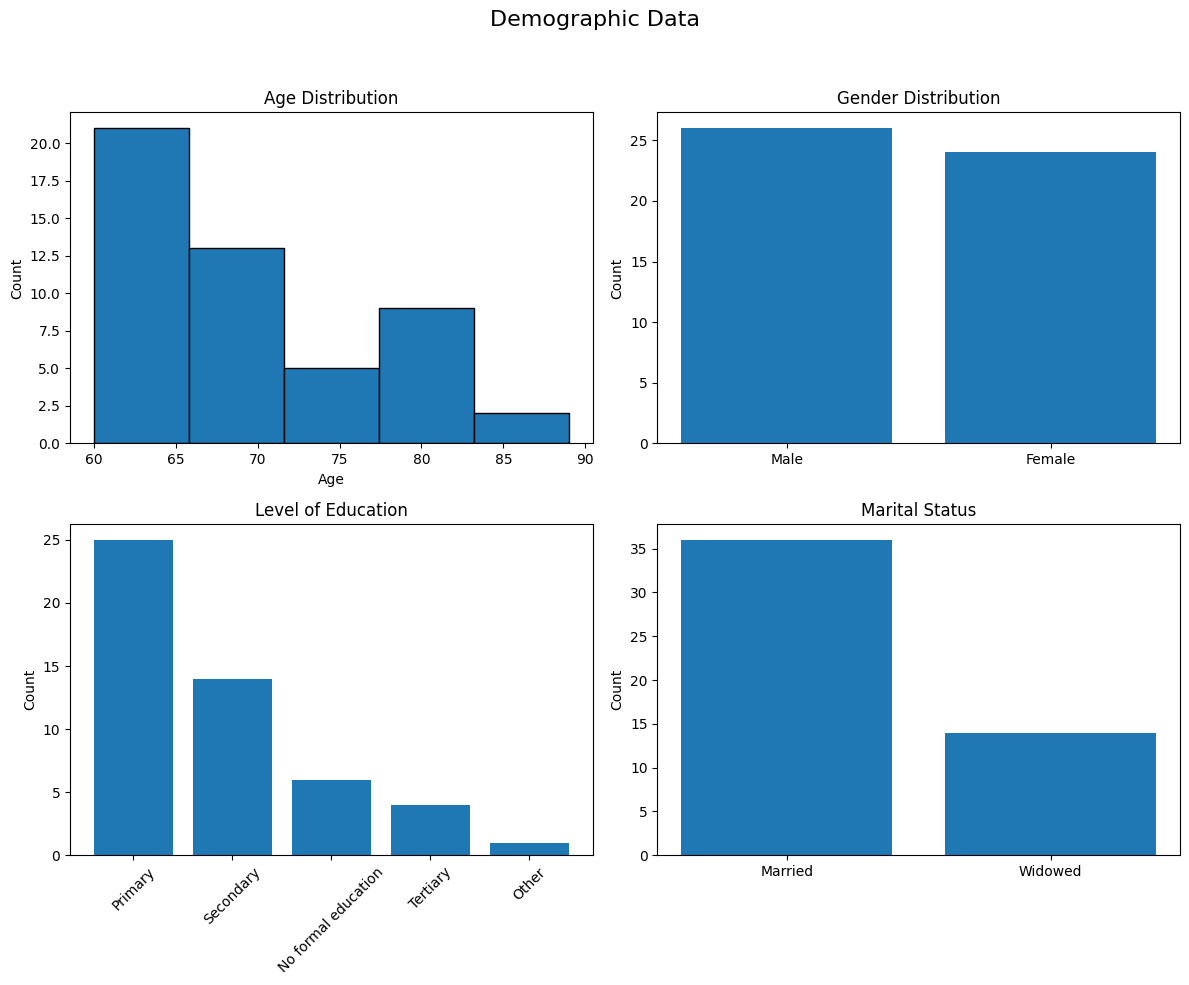

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle('Demographic Data', fontsize=16)
axes = axes.flatten()

# Age Histogram
axes[0].hist(
    df_main['Age'], bins=5, edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Sex Bar Chart
axes[1].bar(
    df_main['Sex'].value_counts().index, 
    df_main['Sex'].value_counts(sort=False).values
)
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')

# Level of Education - bar chart
axes[2].bar(
    df_main['Level of Education'].value_counts().index, 
    df_main['Level of Education'].value_counts().values
)
axes[2].set_title('Level of Education')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

# Marital Status - bar chart
axes[3].bar(
    df_main['Marital Status'].value_counts().index, 
    df_main['Marital Status'].value_counts(sort=False).values
)
axes[3].set_title('Marital Status')
axes[3].set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Awareness of SHA**

*Heard about SHA*

In [13]:
print(df_main['Have you heard about SHA?'].value_counts())
print(df_main['Have you heard about SHA?'].value_counts(normalize=True) * 100)

Have you heard about SHA?
Yes    50
Name: count, dtype: int64
Have you heard about SHA?
Yes    100.0
Name: proportion, dtype: float64


*Sources of information*

In [14]:

print(df_sources['Where did you hear about SHA'].value_counts())
print(df_sources['Where did you hear about SHA'].value_counts(normalize=True) * 100)

Where did you hear about SHA
Health Workers        22
Radio                 17
Television            14
Community Meetings     9
Family/Friends         9
Mobile Phone           2
Social Media           1
No Response            1
Name: count, dtype: int64
Where did you hear about SHA
Health Workers        29.333333
Radio                 22.666667
Television            18.666667
Community Meetings    12.000000
Family/Friends        12.000000
Mobile Phone           2.666667
Social Media           1.333333
No Response            1.333333
Name: proportion, dtype: float64


*Know how to register*

In [15]:
print(df_main['Do you know how someone can register for SHA?'].value_counts())
print(df_main['Do you know how someone can register for SHA?'].value_counts(normalize=True) * 100)

Do you know how someone can register for SHA?
Yes    28
No     22
Name: count, dtype: int64
Do you know how someone can register for SHA?
Yes    56.0
No     44.0
Name: proportion, dtype: float64


*Sufficiency of Knowledge*

In [16]:
print(df_main['In your opinion, how sufficient is the knowledge you have about SHA?'].value_counts())
print(df_main['In your opinion, how sufficient is the knowledge you have about SHA?'].value_counts(normalize=True) * 100)

In your opinion, how sufficient is the knowledge you have about SHA?
Insufficient          15
Sufficient            13
Neutral               12
Very Sufficient        5
Very insufficienct     4
No response            1
Name: count, dtype: int64
In your opinion, how sufficient is the knowledge you have about SHA?
Insufficient          30.0
Sufficient            26.0
Neutral               24.0
Very Sufficient       10.0
Very insufficienct     8.0
No response            2.0
Name: proportion, dtype: float64


*Visualization*

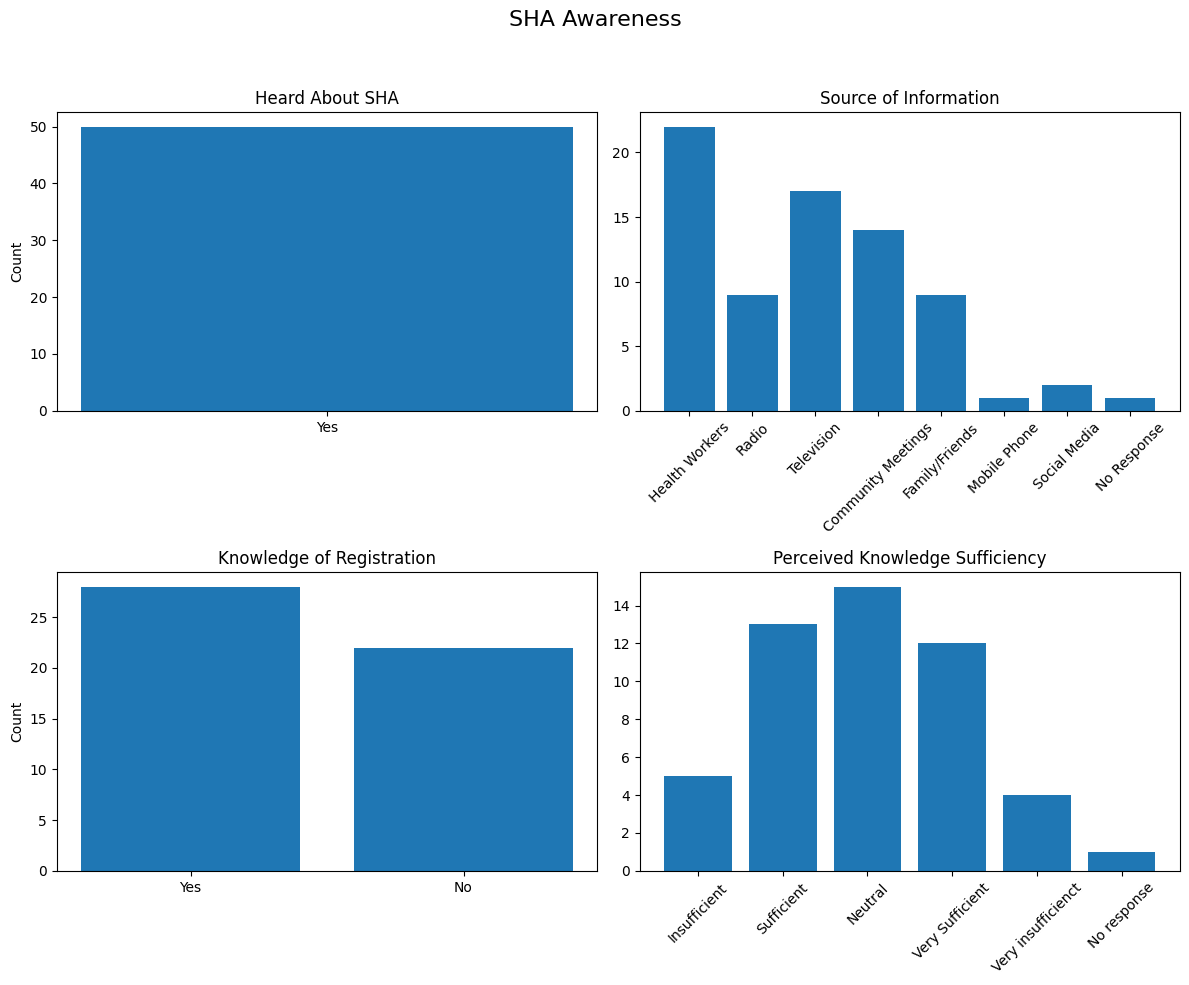

In [17]:
fig,axes = plt.subplots(2,2, figsize=(12,10))
fig.suptitle('SHA Awareness', fontsize=16)
axes = axes.flatten()

# Heard about SHA
axes[0].bar(
    df_main['Have you heard about SHA?'].value_counts().index,
    df_main['Have you heard about SHA?'].value_counts(sort=False).values
)
axes[0].set_title('Heard About SHA')
axes[0].set_ylabel('Count')

# Source of Information
axes[1].bar(
    df_sources['Where did you hear about SHA'].value_counts().index,
    df_sources['Where did you hear about SHA'].value_counts(sort=False).values
)
axes[1].set_title('Source of Information')
axes[1].tick_params(axis='x', rotation=45)

# Knowledge of registration Process
axes[2].bar(
    df_main['Do you know how someone can register for SHA?'].value_counts().index,
    df_main['Do you know how someone can register for SHA?'].value_counts(sort=False).values
)
axes[2].set_title('Knowledge of Registration')
axes[2].set_ylabel('Count')

# Perceived Knowledge Sufficiency
axes[3].bar(
    df_main['In your opinion, how sufficient is the knowledge you have about SHA?'].value_counts().index,
    df_main['In your opinion, how sufficient is the knowledge you have about SHA?'].value_counts(sort=False).values
)
axes[3].set_title('Perceived Knowledge Sufficiency')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


*Knowledge of Registration vs Age*

Do you know how someone can register for SHA?    No   Yes
Age Group                                                
(60, 70]                                       36.0  64.0
(70, 80]                                       61.5  38.5
(80, 90]                                       50.0  50.0


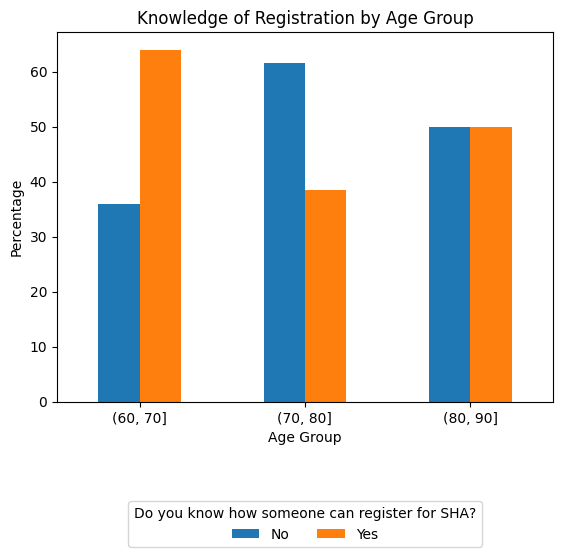

In [18]:
df_main['Age Group'] = pd.cut(df_main['Age'], bins=[60, 70, 80, 90, 100])
ct = pd.crosstab(df_main['Age Group'], df_main['Do you know how someone can register for SHA?'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Knowledge of Registration by Age Group')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'Do you know how someone can register for SHA?')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

*Perceived knowledge vs Education level*

In your opinion, how sufficient is the knowledge you have about SHA?  Insufficient  \
Level of Education                                                                   
No formal education                                                           33.3   
Other                                                                          0.0   
Primary                                                                       28.0   
Secondary                                                                     35.7   
Tertiary                                                                      25.0   

In your opinion, how sufficient is the knowledge you have about SHA?  Neutral  \
Level of Education                                                              
No formal education                                                       0.0   
Other                                                                     0.0   
Primary                                                                  

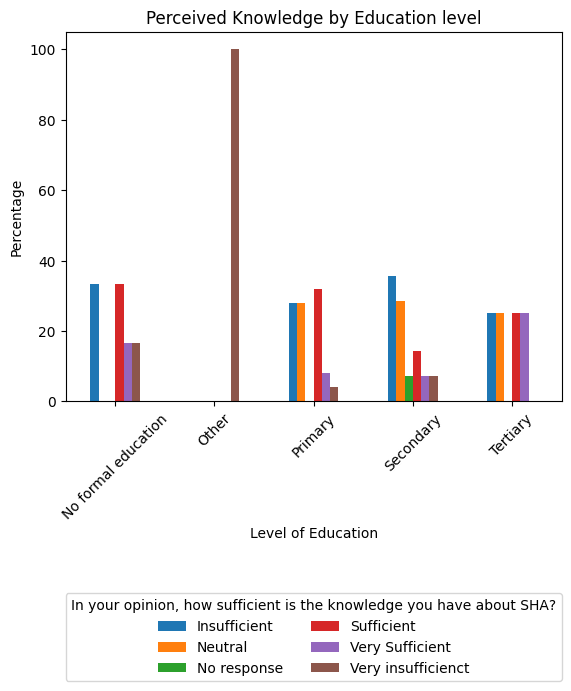

In [19]:
ct = pd.crosstab(df_main['Level of Education'], df_main['In your opinion, how sufficient is the knowledge you have about SHA?'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Perceived Knowledge by Education level')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5), ncol=2, title = 'In your opinion, how sufficient is the knowledge you have about SHA?')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

**Perceived Impact of SHA**

*Enrollment Status*

In [20]:
print(df_main['Are you currently registered under SHA?'].value_counts())
print(df_main['Are you currently registered under SHA?'].value_counts(normalize=True) * 100)

Are you currently registered under SHA?
Yes    44
No      6
Name: count, dtype: int64
Are you currently registered under SHA?
Yes    88.0
No     12.0
Name: proportion, dtype: float64


*Length of enrollment*

In [21]:
print(df_main['How long have you been enrolled?'].value_counts())
print(df_main['How long have you been enrolled?'].value_counts(normalize=True) * 100)

How long have you been enrolled?
1-2 years           33
Less than 1 year     8
No response          6
Not Sure             3
Name: count, dtype: int64
How long have you been enrolled?
1-2 years           66.0
Less than 1 year    16.0
No response         12.0
Not Sure             6.0
Name: proportion, dtype: float64


*How often do you visit a health facility compared to before enrolling for SHA*

In [22]:
print(df_main['How often do you visit a health facility now compared to before enrolling?'].value_counts())
print(df_main['How often do you visit a health facility now compared to before enrolling?'].value_counts(normalize=True) * 100)

How often do you visit a health facility now compared to before enrolling?
The Same       26
More Often     17
No response     6
Less Often      1
Name: count, dtype: int64
How often do you visit a health facility now compared to before enrolling?
The Same       52.0
More Often     34.0
No response    12.0
Less Often      2.0
Name: proportion, dtype: float64


*Types of services accessed*

In [23]:
print(df_services['What types of health services have you accessed through SHA?'].value_counts())
print(df_services['What types of health services have you accessed through SHA?'].value_counts(normalize=True) * 100)

What types of health services have you accessed through SHA?
Outpatient Services    38
Medications            33
Laboratory Tests       26
Inpatient Services     11
No response             7
Other                   5
Name: count, dtype: int64
What types of health services have you accessed through SHA?
Outpatient Services    31.666667
Medications            27.500000
Laboratory Tests       21.666667
Inpatient Services      9.166667
No response             5.833333
Other                   4.166667
Name: proportion, dtype: float64


*Reduced Spending*

In [24]:
print(df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'].value_counts())
print(df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'].value_counts(normalize=True) * 100)

Has SHA helped reduce the amount of money you personally spend on healthcare?
Yes            35
No              9
No response     6
Name: count, dtype: int64
Has SHA helped reduce the amount of money you personally spend on healthcare?
Yes            70.0
No             18.0
No response    12.0
Name: proportion, dtype: float64


In [25]:
print(df_main['Are there healtcare services you stilll have to pay for after enrolling in SHA?'].value_counts())
print(df_main['Are there healtcare services you stilll have to pay for after enrolling in SHA?'].value_counts(normalize=True) * 100)

Are there healtcare services you stilll have to pay for after enrolling in SHA?
Yes            27
No             13
No response     7
Name: count, dtype: int64
Are there healtcare services you stilll have to pay for after enrolling in SHA?
Yes            57.446809
No             27.659574
No response    14.893617
Name: proportion, dtype: float64


*Visualization*

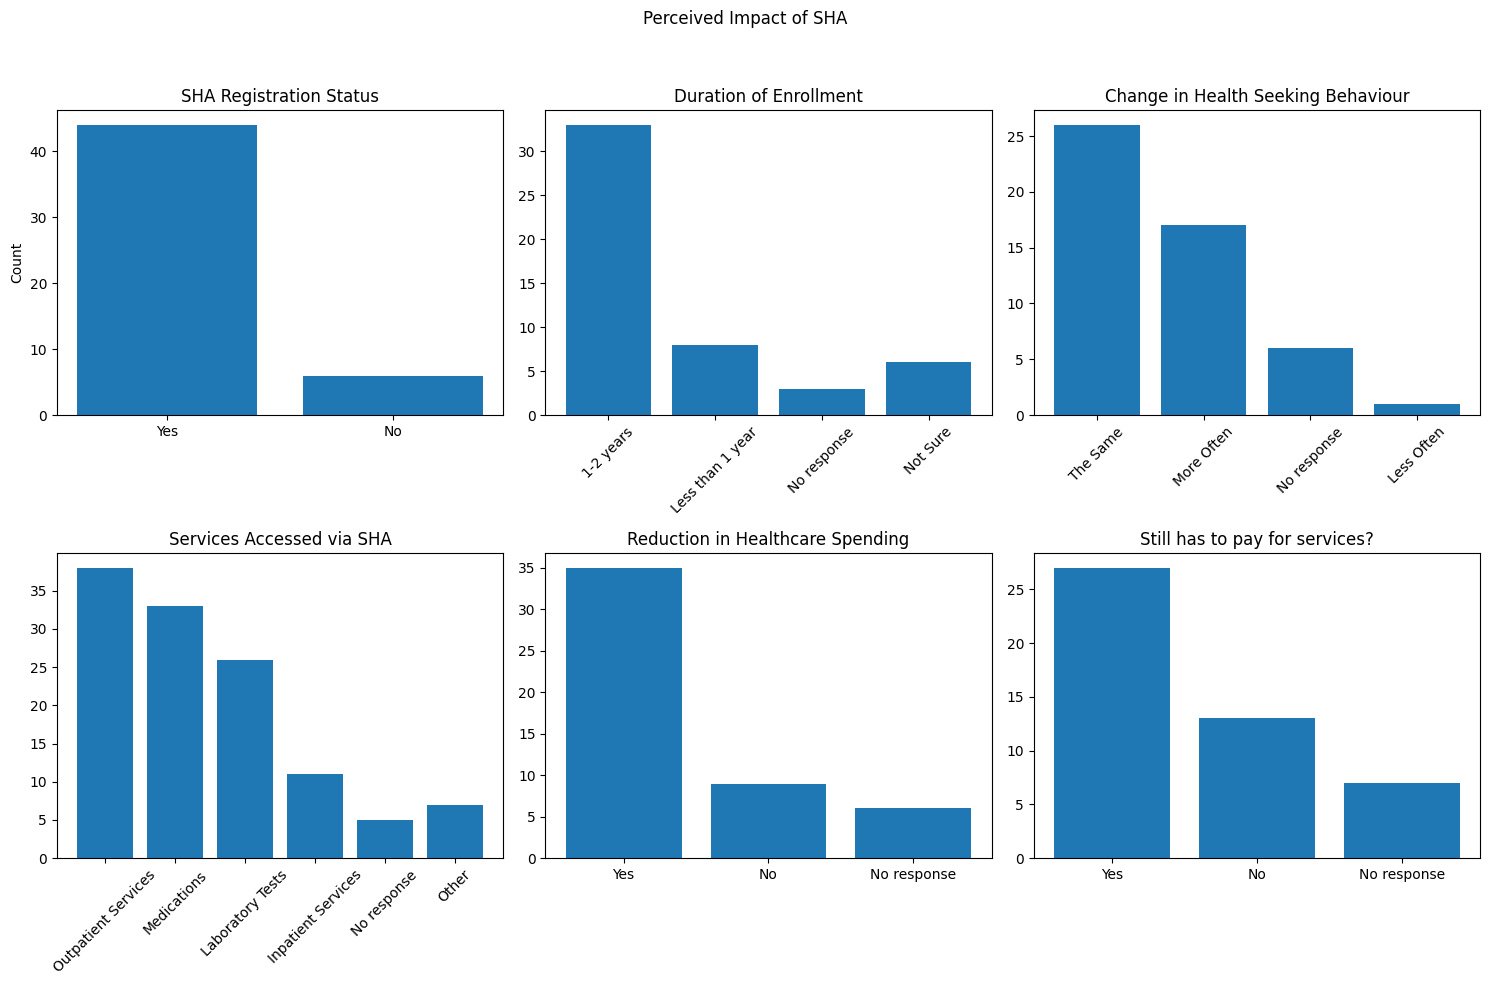

In [26]:
fig, axes = plt.subplots(2,3, figsize=(15,10))
fig.suptitle('Perceived Impact of SHA')
axes = axes.flatten()

# Registration Status
axes[0].bar(
    df_main['Are you currently registered under SHA?'].value_counts().index,
    df_main['Are you currently registered under SHA?'].value_counts(sort=False).values
)
axes[0].set_title('SHA Registration Status')
axes[0].set_ylabel('Count')

# Duration of Enrollment
axes[1].bar(
    df_main['How long have you been enrolled?'].value_counts().index,
    df_main['How long have you been enrolled?'].value_counts(sort=False).values
)
axes[1].set_title('Duration of Enrollment')
axes[1].tick_params(axis='x',rotation=45)

# Change in health seeking behaviour
axes[2].bar(
    df_main['How often do you visit a health facility now compared to before enrolling?'].value_counts().index,
    df_main['How often do you visit a health facility now compared to before enrolling?'].value_counts(sort=False).values
)
axes[2].set_title('Change in Health Seeking Behaviour')
axes[2].tick_params(axis='x', rotation=45)

# Types of Services accessed
axes[3].bar(
    df_services['What types of health services have you accessed through SHA?'].value_counts().index,
    df_services['What types of health services have you accessed through SHA?'].value_counts(sort=False).values,
)
axes[3].set_title('Services Accessed via SHA')
axes[3].tick_params(axis='x', rotation=45)

# Reduction in Personal Spending
axes[4].bar(
    df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'].value_counts().index,
    df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'].value_counts(sort=False).values
)
axes[4].set_title('Reduction in Healthcare Spending')

axes[5].bar(
    df_main['Are there healtcare services you stilll have to pay for after enrolling in SHA?'].value_counts().index,
    df_main['Are there healtcare services you stilll have to pay for after enrolling in SHA?'].value_counts(sort=False).values
)
axes[5].set_title('Still has to pay for services?')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

*Registration vs Facility Visits*

How often do you visit a health facility now compared to before enrolling?  Less Often  \
Are you currently registered under SHA?                                                  
No                                                                                 0.0   
Yes                                                                                2.3   

How often do you visit a health facility now compared to before enrolling?  More Often  \
Are you currently registered under SHA?                                                  
No                                                                                 0.0   
Yes                                                                               38.6   

How often do you visit a health facility now compared to before enrolling?  No response  \
Are you currently registered under SHA?                                                   
No                                                                                100.0   
Yes  

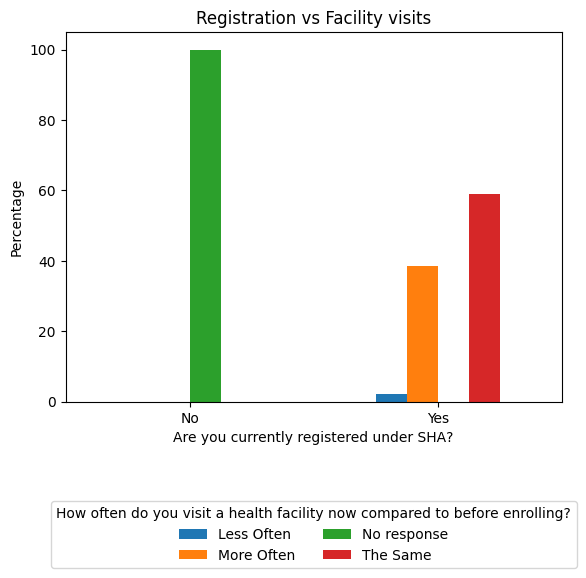

In [27]:
ct = pd.crosstab(df_main['Are you currently registered under SHA?'], df_main['How often do you visit a health facility now compared to before enrolling?'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Registration vs Facility visits')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'How often do you visit a health facility now compared to before enrolling?')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

*Spending Reduction Vs Enrollment duration*

Has SHA helped reduce the amount of money you personally spend on healthcare?    No  \
How long have you been enrolled?                                                      
1-2 years                                                                      18.2   
Less than 1 year                                                               37.5   
No response                                                                     0.0   
Not Sure                                                                        0.0   

Has SHA helped reduce the amount of money you personally spend on healthcare?  No response  \
How long have you been enrolled?                                                             
1-2 years                                                                              0.0   
Less than 1 year                                                                       0.0   
No response                                                                          100.0   
Not Sur

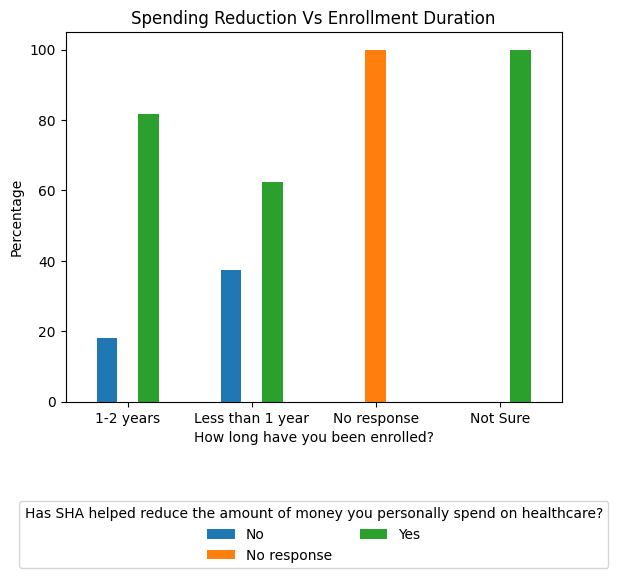

In [28]:
ct = pd.crosstab(
    df_main['How long have you been enrolled?'],
    df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'],
    normalize='index'
) * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Spending Reduction Vs Enrollment Duration')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'Has SHA helped reduce the amount of money you personally spend on healthcare?')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

**Barriers to Utilization**

*Difficulties experienced*

In [29]:
print(df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'].value_counts());
print(df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'].value_counts(normalize=True) * 100);

Have you experienced any difficulties when trying to access healthcare services through SHA?
Other                         32
Lack of information            9
Technological difficulties     6
Transport Cost                 3
Difficulty registering         3
No Response                    2
Name: count, dtype: int64
Have you experienced any difficulties when trying to access healthcare services through SHA?
Other                         58.181818
Lack of information           16.363636
Technological difficulties    10.909091
Transport Cost                 5.454545
Difficulty registering         5.454545
No Response                    3.636364
Name: proportion, dtype: float64


*Ease of registration*

In [30]:
print(df_main['Do you think the registration process for SHA is easy ordifficult?'].value_counts())
print(df_main['Do you think the registration process for SHA is easy ordifficult?'].value_counts(normalize=True) * 100)

Do you think the registration process for SHA is easy ordifficult?
Easy           20
Very easy      17
Neutral         7
Hard            5
No response     1
Name: count, dtype: int64
Do you think the registration process for SHA is easy ordifficult?
Easy           40.0
Very easy      34.0
Neutral        14.0
Hard           10.0
No response     2.0
Name: proportion, dtype: float64


*Visualization*

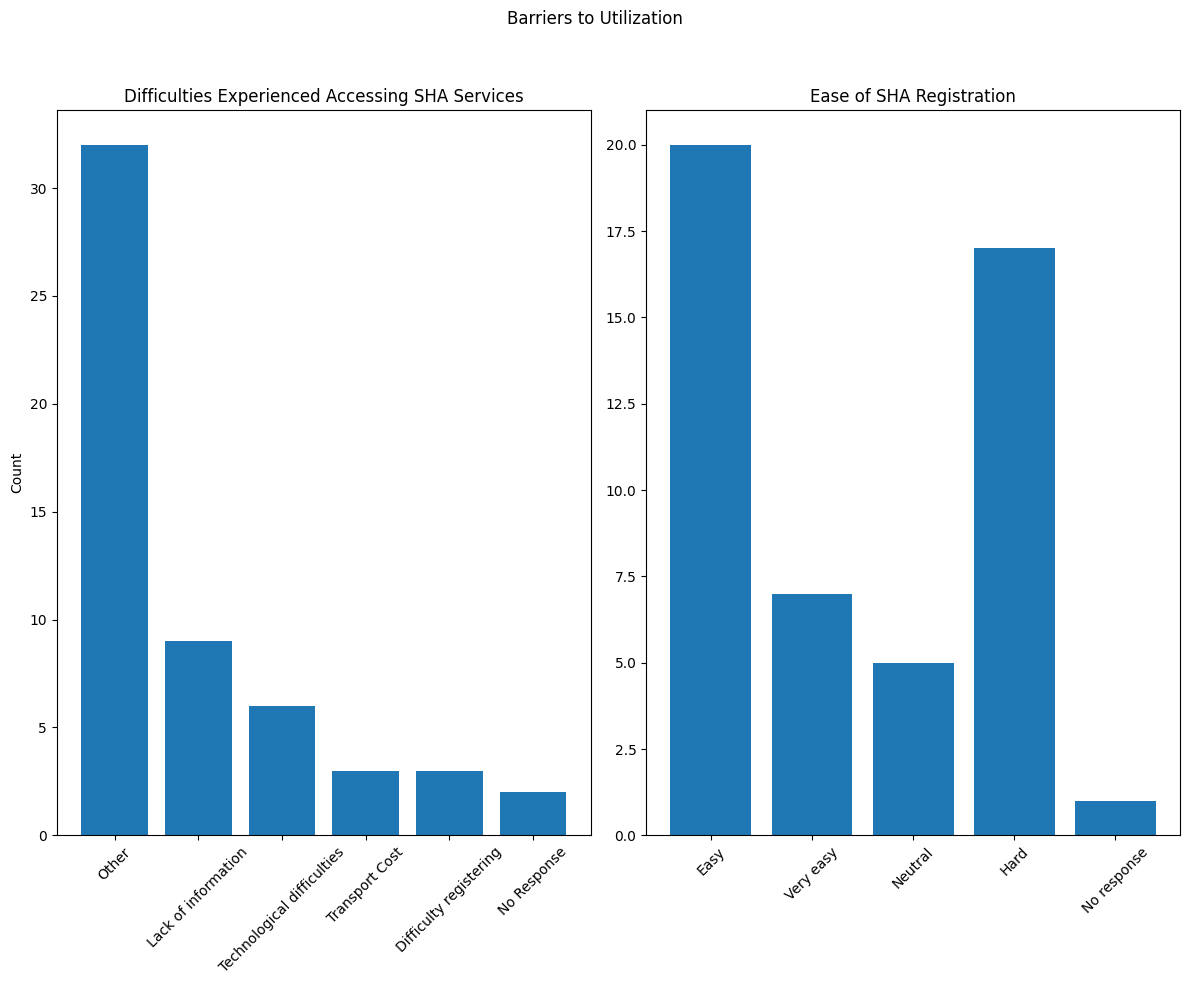

In [31]:
fig, axes = plt.subplots(1,2, figsize=(12,10))
fig.suptitle('Barriers to Utilization')
axes = axes.flatten()

# Difficulties Experienced
axes[0].bar(
    df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'].value_counts().index,
    df_difficulties['Have you experienced any difficulties when trying to access healthcare services through SHA?'].value_counts(sort=False).values
)
axes[0].set_title('Difficulties Experienced Accessing SHA Services')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Ease of Registration
axes[1].bar(
    df_main['Do you think the registration process for SHA is easy ordifficult?'].value_counts().index,
    df_main['Do you think the registration process for SHA is easy ordifficult?'].value_counts(sort=False).values
)
axes[1].set_title('Ease of SHA Registration')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

**Satisfaction with SHA Services**

*SHA has improved my ability to receive medical care*

In [32]:
print(df_main['SHA has improved my ability to receive medical care'].value_counts())
print(df_main['SHA has improved my ability to receive medical care'].value_counts(normalize=True) * 100)

SHA has improved my ability to receive medical care
Strongly Agree    20
Agree             17
Neutral            7
No response        5
Disagree           1
Name: count, dtype: int64
SHA has improved my ability to receive medical care
Strongly Agree    40.0
Agree             34.0
Neutral           14.0
No response       10.0
Disagree           2.0
Name: proportion, dtype: float64


*Medicines are usually available when I visit the facility*

In [33]:
print(df_main['Medicines are usually available when I visit the facility'].value_counts())
print(df_main['Medicines are usually available when I visit the facility'].value_counts(normalize=True) * 100)

Medicines are usually available when I visit the facility
Neutral              16
Strongly Agree       11
Disagree             10
Agree                 6
No response           5
Strongly Disagree     2
Name: count, dtype: int64
Medicines are usually available when I visit the facility
Neutral              32.0
Strongly Agree       22.0
Disagree             20.0
Agree                12.0
No response          10.0
Strongly Disagree     4.0
Name: proportion, dtype: float64


*The services covered by SHA meet my healthcare needs*

In [34]:
print(df_main['The services covered by SHA meet my healthcare needs'].value_counts())
print(df_main['The services covered by SHA meet my healthcare needs'].value_counts(normalize=True) * 100)

The services covered by SHA meet my healthcare needs
Strongly Agree       22
Agree                12
Neutral               8
No response           5
Disagree              2
Strongly Disagree     1
Name: count, dtype: int64
The services covered by SHA meet my healthcare needs
Strongly Agree       44.0
Agree                24.0
Neutral              16.0
No response          10.0
Disagree              4.0
Strongly Disagree     2.0
Name: proportion, dtype: float64


*SHA has reduced my personal spending on SHA*

In [35]:
print(df_main['SHA has reduced my personal spending on SHA'].value_counts())
print(df_main['SHA has reduced my personal spending on SHA'].value_counts(normalize=True) * 100)

SHA has reduced my personal spending on SHA
Strongly Agree       21
Agree                14
Neutral               8
No response           5
Strongly Disagree     2
Name: count, dtype: int64
SHA has reduced my personal spending on SHA
Strongly Agree       42.0
Agree                28.0
Neutral              16.0
No response          10.0
Strongly Disagree     4.0
Name: proportion, dtype: float64


*I feel financially protected when seeking treatment under SHA*

In [36]:
print(df_main['I feel financially protected when seeking treatment under SHA'].value_counts())
print(df_main['I feel financially protected when seeking treatment under SHA'].value_counts(normalize=True) * 100)

I feel financially protected when seeking treatment under SHA
Strongly Agree       19
Agree                16
Neutral               7
No response           5
Strongly Disagree     2
Disagree              1
Name: count, dtype: int64
I feel financially protected when seeking treatment under SHA
Strongly Agree       38.0
Agree                32.0
Neutral              14.0
No response          10.0
Strongly Disagree     4.0
Disagree              2.0
Name: proportion, dtype: float64


*Would you recommend SHA to older adults*

In [37]:
print(df_main['Would you recommend SHA to older adults?'].value_counts())
print(df_main['Would you recommend SHA to older adults?'].value_counts(normalize=True) * 100)

Would you recommend SHA to older adults?
Yes         45
Not Sure     4
No           1
Name: count, dtype: int64
Would you recommend SHA to older adults?
Yes         90.0
Not Sure     8.0
No           2.0
Name: proportion, dtype: float64


*Visualization*

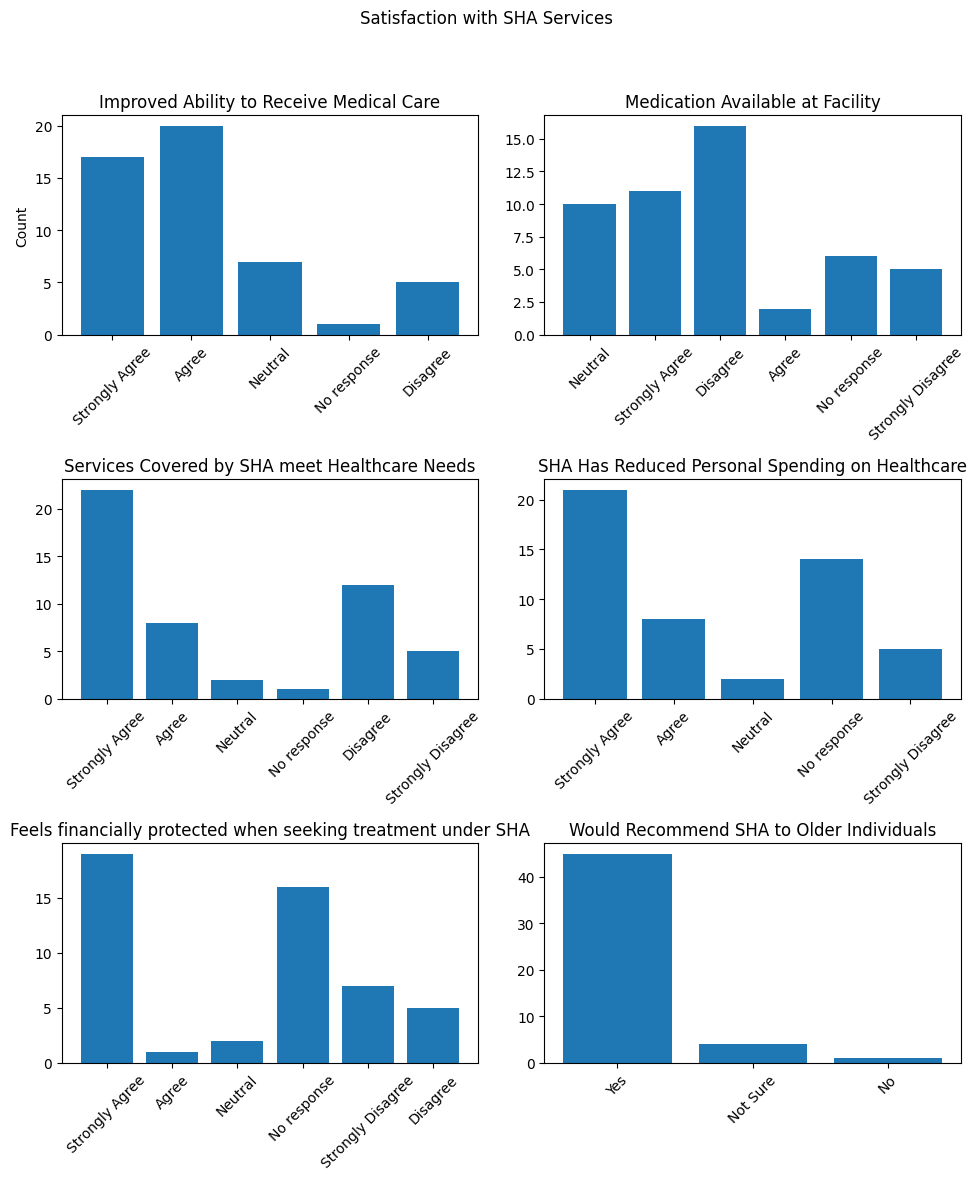

In [38]:
fig,axes = plt.subplots(3,2, figsize=(10,12))
fig.suptitle('Satisfaction with SHA Services')
axes = axes.flatten()

# SHA has improved my ability to receive medical care
axes[0].bar(
    df_main['SHA has improved my ability to receive medical care'].value_counts().index,
    df_main['SHA has improved my ability to receive medical care'].value_counts(sort=False).values
)
axes[0].set_title('Improved Ability to Receive Medical Care')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Medicine availability
axes[1].bar(
    df_main['Medicines are usually available when I visit the facility'].value_counts().index,
    df_main['Medicines are usually available when I visit the facility'].value_counts(sort=False).values
)
axes[1].set_title('Medication Available at Facility')
axes[1].tick_params(axis='x', rotation=45)

# Services Cover Healthcare needs
axes[2].bar(
    df_main['The services covered by SHA meet my healthcare needs'].value_counts().index,
    df_main['The services covered by SHA meet my healthcare needs'].value_counts(sort=False).values
)
axes[2].set_title('Services Covered by SHA meet Healthcare Needs')
axes[2].tick_params(axis='x', rotation=45)

# SHA Has Reduced Personal Healthcare spending
axes[3].bar(
    df_main['SHA has reduced my personal spending on SHA'].value_counts().index,
    df_main['SHA has reduced my personal spending on SHA'].value_counts(sort=False).values
)
axes[3].set_title('SHA Has Reduced Personal Spending on Healthcare')
axes[3].tick_params(axis='x', rotation=45)

# Financial Protection
axes[4].bar(
    df_main['I feel financially protected when seeking treatment under SHA'].value_counts().index,
    df_main['I feel financially protected when seeking treatment under SHA'].value_counts(sort=False).values
)
axes[4].set_title('Feels financially protected when seeking treatment under SHA')
axes[4].tick_params(axis='x', rotation=45)

# Would you recommend SHA to older adults?
axes[5].bar(
    df_main['Would you recommend SHA to older adults?'].value_counts().index,
    df_main['Would you recommend SHA to older adults?'].value_counts(sort=False).values
)
axes[5].set_title('Would Recommend SHA to Older Individuals')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*Satisfaction Vs Enrollment*

SHA has improved my ability to receive medical care  Agree  Disagree  Neutral  \
Are you currently registered under SHA?                                         
No                                                     0.0       0.0     16.7   
Yes                                                   38.6       2.3     13.6   

SHA has improved my ability to receive medical care  No response  \
Are you currently registered under SHA?                            
No                                                          83.3   
Yes                                                          0.0   

SHA has improved my ability to receive medical care  Strongly Agree  
Are you currently registered under SHA?                              
No                                                              0.0  
Yes                                                            45.5  


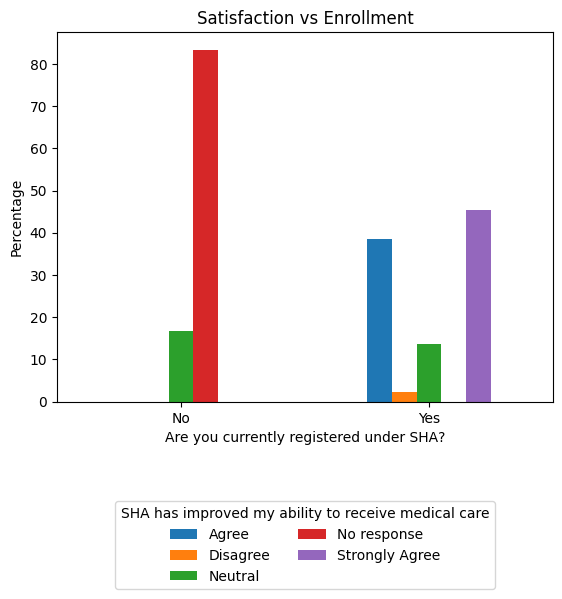

In [39]:
ct = pd.crosstab(df_main['Are you currently registered under SHA?'], df_main['SHA has improved my ability to receive medical care'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Satisfaction vs Enrollment')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'SHA has improved my ability to receive medical care')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

*Financial Protection vs Cost Reduction*

I feel financially protected when seeking treatment under SHA  Agree  \
Has SHA helped reduce the amount of money you p...                     
No                                                              11.1   
No response                                                      0.0   
Yes                                                             42.9   

I feel financially protected when seeking treatment under SHA  Disagree  \
Has SHA helped reduce the amount of money you p...                        
No                                                                 11.1   
No response                                                         0.0   
Yes                                                                 0.0   

I feel financially protected when seeking treatment under SHA  Neutral  \
Has SHA helped reduce the amount of money you p...                       
No                                                                33.3   
No response                              

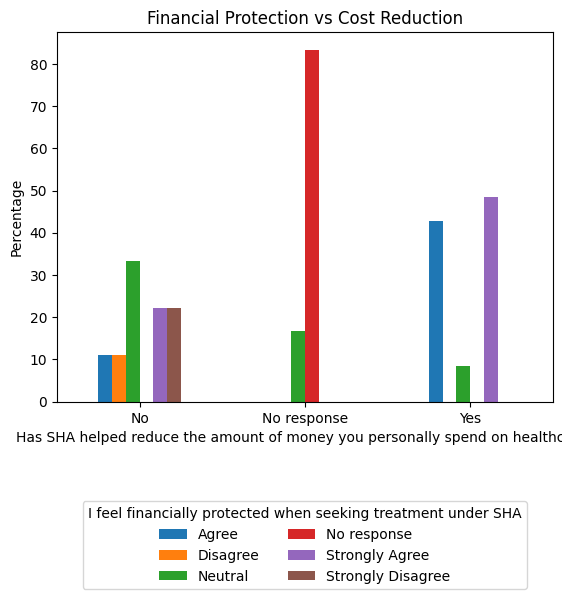

In [40]:
ct = pd.crosstab(df_main['Has SHA helped reduce the amount of money you personally spend on healthcare?'], df_main['I feel financially protected when seeking treatment under SHA'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Financial Protection vs Cost Reduction')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'I feel financially protected when seeking treatment under SHA')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

*Recommendation vs Satisfaction*

SHA has improved my ability to receive medical care  Agree  Disagree  Neutral  \
Would you recommend SHA to older adults?                                        
No                                                     0.0       0.0    100.0   
Not Sure                                               0.0       0.0      0.0   
Yes                                                   37.8       2.2     13.3   

SHA has improved my ability to receive medical care  No response  \
Would you recommend SHA to older adults?                           
No                                                           0.0   
Not Sure                                                   100.0   
Yes                                                          2.2   

SHA has improved my ability to receive medical care  Strongly Agree  
Would you recommend SHA to older adults?                             
No                                                              0.0  
Not Sure                                   

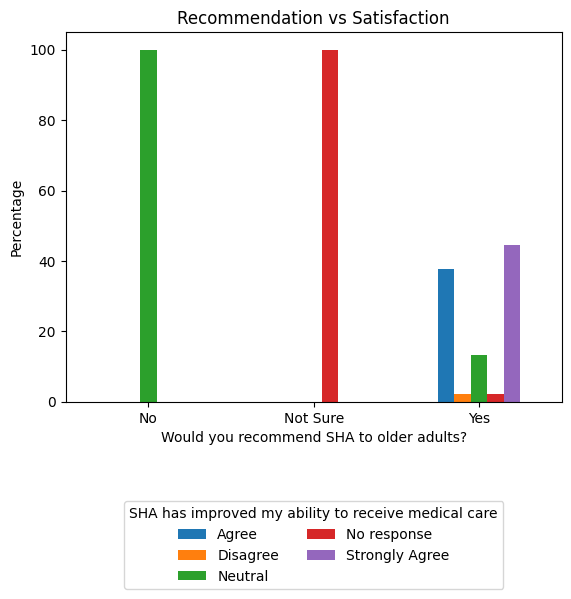

In [41]:
ct = pd.crosstab(df_main['Would you recommend SHA to older adults?'], df_main['SHA has improved my ability to receive medical care'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=False)
plt.title('Recommendation vs Satisfaction')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, title = 'SHA has improved my ability to receive medical care')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()